In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузить train.csv
df = pd.read_csv('house.csv')

In [3]:
# вывести 10 строк
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
# Посмотреть .info() и .shape.
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

(1460, 81)

In [5]:
# Вывести список колонок
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
# и их типы.
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [7]:
# Удалить все неиспользуемые признаки (оставить только нужные 7 + SalePrice)
df = df[['GrLivArea', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'OverallQual', 'Neighborhood', 'SalePrice']]

In [8]:
# посмотреть сколько столбцов и строк
df.shape

(1460, 8)

In [9]:
# Сохранить облегчённый датасет в отдельный CSV (clean_data.csv)
df.to_csv('clean_data.csv', index=False)

In [10]:
# Какие есть уникальные районы (Neighborhood)
df['Neighborhood'].unique()

array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

In [11]:
# Сколько уникальных районов (Neighborhood)
df['Neighborhood'].nunique()

25

In [12]:
# Средняя цена по району — топ 5 дорогих районов
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).head(5)

,SalePrice
Neighborhood,
NoRidge,335295.317073
NridgHt,316270.623377
StoneBr,310499.000000
Timber,242247.447368
Veenker,238772.727273


In [13]:
# Сколько домов было построено после 2000 года?
(df['YearBuilt'] > 2000).sum()

np.int64(364)

In [14]:
# Средняя жилая площадь (GrLivArea) по уровню качества (OverallQual).
df.groupby('OverallQual')['GrLivArea'].mean().round(2)

,GrLivArea
OverallQual,
1,619.00
2,572.67
3,1119.15
4,1106.67
5,1250.75
6,1465.87
7,1703.83
8,1947.61
9,2077.51


In [15]:
# Есть ли дома с нулевым подвалом? Посчитать долю таких домов.
print(f'Доля домов с нулевым подвалом: {(df[df["TotalBsmtSF"] == 0].shape[0] / df.shape[0]) * 100:.2f}%')

Доля домов с нулевым подвалом: 2.53%


In [16]:
# Группировка по GarageCars и средняя цена.
df.groupby('GarageCars')['SalePrice'].mean().round(2)

,SalePrice
GarageCars,
0,103317.28
1,128116.69
2,183851.66
3,309636.12
4,192655.80


In [17]:
# Сколько домов имеют 2+ ванных комнаты (FullBath)?
df.loc[df['FullBath'] > 2].shape[0]

33

In [18]:
# Район с наибольшим количеством домов.
df['Neighborhood'].value_counts().head(1)

,count
Neighborhood,
NAmes,225


In [19]:
# Корреляция GrLivArea, TotalBsmtSF, OverallQual, GarageCars с SalePrice.
new_corr = df[['GrLivArea', 'TotalBsmtSF', 'OverallQual', 'GarageCars', 'SalePrice']].corr()

<Axes: >

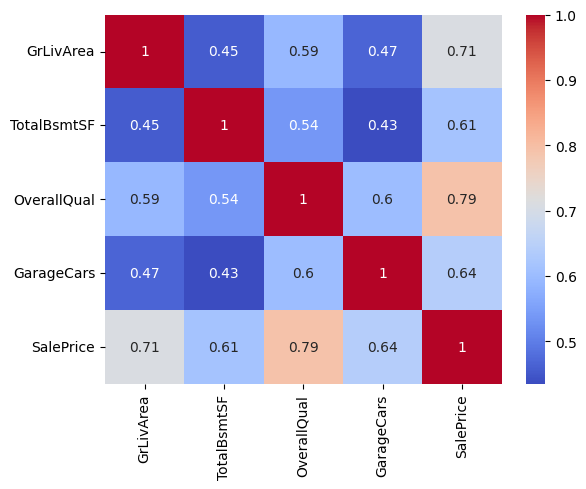

In [20]:
# сравнить все столбцы друг другу
sns.heatmap(new_corr, annot=True, cmap='coolwarm')

In [21]:
# Построить рейтинг районов по средней цене и сохранить в CSV.
rat_df = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).round(2)
rat_df.to_csv('rating.csv')
print(rat_df)

Neighborhood
NoRidge    335295.32
NridgHt    316270.62
StoneBr    310499.00
Timber     242247.45
Veenker    238772.73
Somerst    225379.84
ClearCr    212565.43
Crawfor    210624.73
CollgCr    197965.77
Blmngtn    194870.88
Gilbert    192854.51
NWAmes     189050.07
SawyerW    186555.80
Mitchel    156270.12
NAmes      145847.08
NPkVill    142694.44
SWISU      142591.36
Blueste    137500.00
Sawyer     136793.14
OldTown    128225.30
Edwards    128219.70
BrkSide    124834.05
BrDale     104493.75
IDOTRR     100123.78
MeadowV     98576.47
Name: SalePrice, dtype: float64


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
# Обработать пропущенные значения (если есть).
df.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
OverallQual,0
Neighborhood,0
SalePrice,0


In [24]:
# Преобразовать Neighborhood в числовой (one-hot или LabelEncoder).
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True).astype(int)

In [25]:
# Нормализовать числовые признаки (MinMaxScaler или StandardScaler).
scaler = StandardScaler()
features = df.drop(columns=['SalePrice'])
scaled_data = scaler.fit_transform(features)

In [26]:
scaled_data

array([[ 0.37033344,  1.05099379,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.48251191,  0.15673371,  0.31172464, ..., -0.13199092,
        -0.16347148, 11.47725023],
       [ 0.51501256,  0.9847523 ,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       ...,
       [ 1.56964722, -1.00249232, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.83278768, -0.70440562, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.49393395, -0.20759447, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888]])

In [27]:
# Разделить данные на X и y, где y = SalePrice.
x = scaled_data
y = df['SalePrice']

In [28]:
# Разбить данные на train/test (train_test_split, 80/20).
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
x_test.shape

(292, 30)

ЭТАП 3: Обучение модели (Linear Regression)

In [30]:
!pip install xgboost

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.metrics import r2_score
import joblib

In [32]:
# Построить модель LinearRegression() из sklearn.linear_model.
lin_model = LinearRegression()
grad_model = GradientBoostingClassifier()
random_model = RandomForestRegressor()
xgb_model = XGBRegressor()

In [33]:
# Обучить модель на тренировочных данных.
lin_model.fit(x_train, y_train)

LinearRegression()

In [34]:
grad_model.fit(x_train, y_train)

GradientBoostingClassifier()

In [35]:
random_model.fit(x_train, y_train)

RandomForestRegressor()

In [36]:
xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [37]:
# Сделать предсказания на тесте.
y_predict_lin = lin_model.predict(x_test)
y_predict_grad = grad_model.predict(x_test)
y_predict_random = random_model.predict(x_test)
y_predict_xgb = xgb_model.predict(x_test)

In [38]:
# Посчитать метрики: MAE, MSE, RMSE, R²
print('r2_score:')
print(f'Model Lin: {r2_score(y_test, y_predict_lin)}')
print(f'Model Grad: {r2_score(y_test, y_predict_grad)}')
print(f'Model Random: {r2_score(y_test, y_predict_random)}')
print(f'Model XGB: {r2_score(y_test, y_predict_xgb)}')

r2_score:
Model Lin: 0.8267380266474198
Model Grad: 0.0012876633014653471
Model Random: 0.8913651483649483
Model XGB: 0.8994290828704834


In [39]:
# Сохранить модель (joblib или pickle).
joblib.dump(lin_model, 'lin_model.pkl')
joblib.dump(lin_model, 'grad_model.pkl')
joblib.dump(lin_model, 'random_model.pkl')
joblib.dump(lin_model, 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [40]:
df.columns

Index(['GrLivArea', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'FullBath',
       'OverallQual', 'SalePrice', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker'],
      dtype='object')

In [41]:
li = []
for i in df:
  subword = 'Neighborhood_'
  if subword in i:
    li.append(i[len(subword):])
print(li)

['Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber', 'Veenker']
